In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
# Cargar el dataset
df = pd.read_csv('diabetes.csv')

# Mostrar las primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())
print("\nInformación del dataset:")
print(df.info())

Primeras 5 filas del dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               76

# Descripción de las variables:
- Pregnancies: Número de embarazos

- Glucose: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa

- BloodPressure: Presión arterial diastólica (mm Hg)

- SkinThickness: Grosor del pliegue cutáneo del tríceps (mm)

- Insulin: Insulina sérica de 2 horas (mu U/ml)

- BMI: Índice de masa corporal (peso en kg/(altura en m)^2)

- DiabetesPedigreeFunction: Función que califica la probabilidad de diabetes basada en antecedentes familiares

- Age: Edad en años

- Outcome: Variable objetivo (1 = diabetes, 0 = no diabetes)

- Contexto: Este conjunto de datos contiene información médica de pacientes y busca predecir si una persona tiene diabetes basándose en diversas mediciones clínicas.

In [4]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
print(df.describe())

# Información sobre valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

Estadísticas descriptivas:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min     

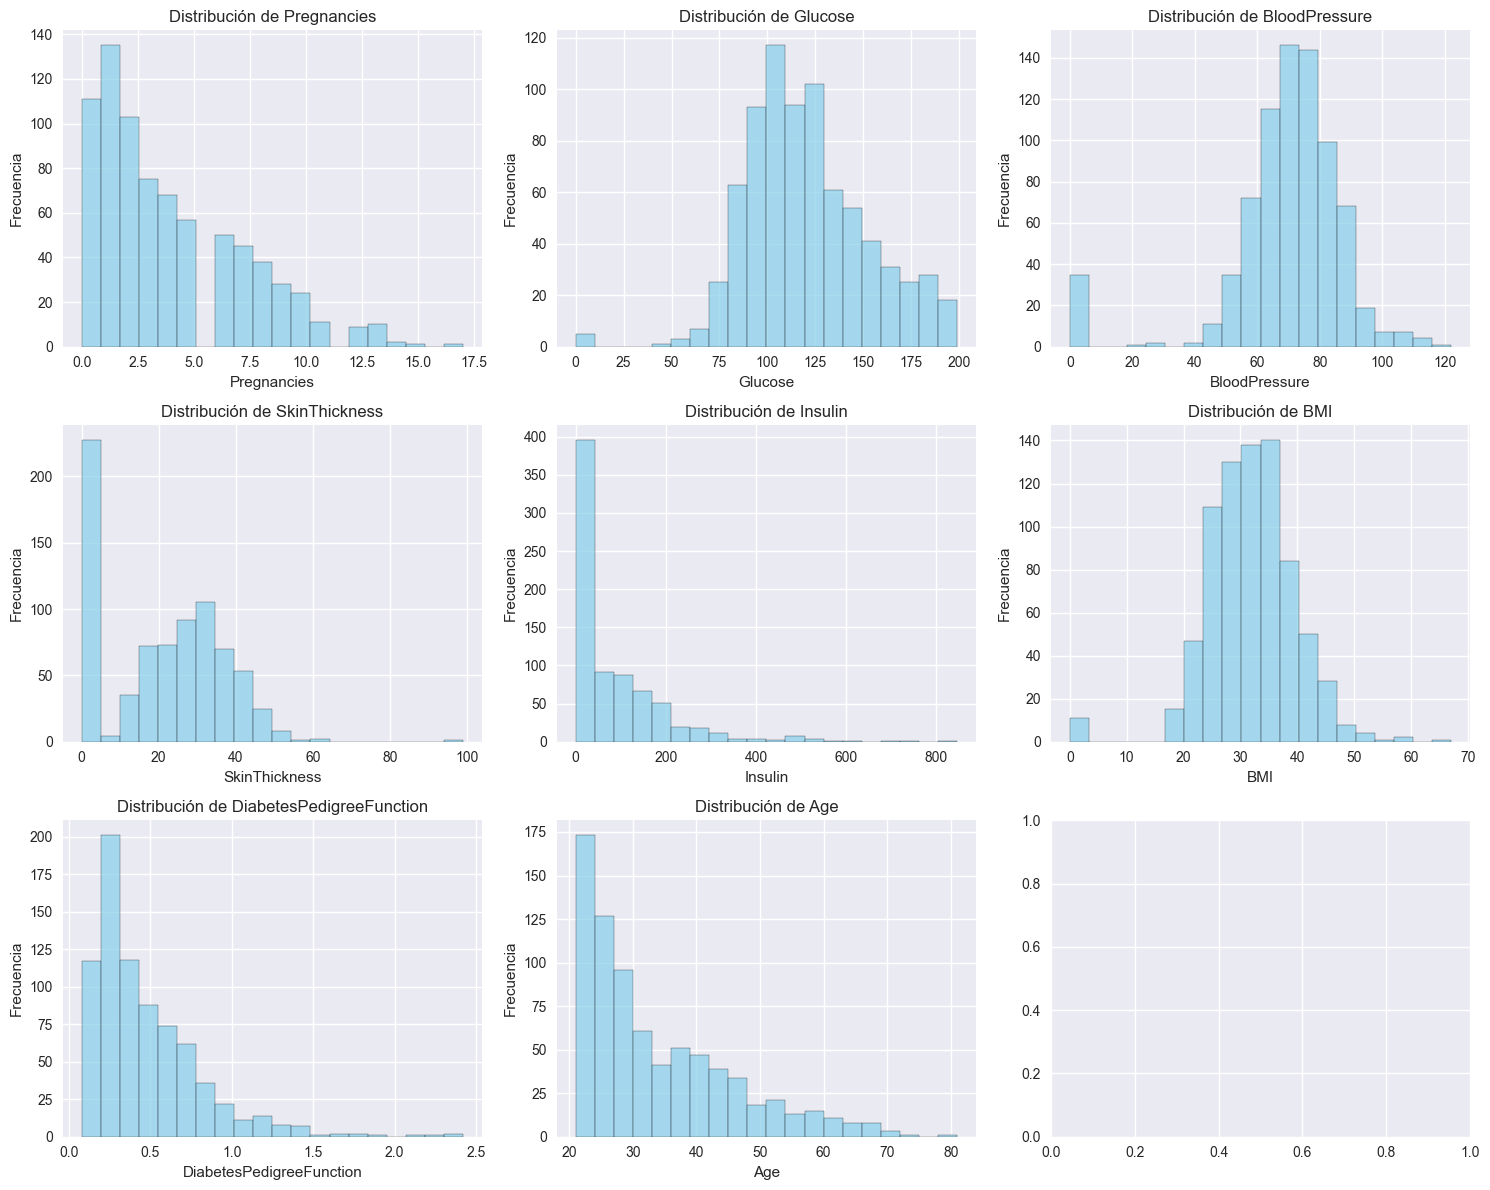

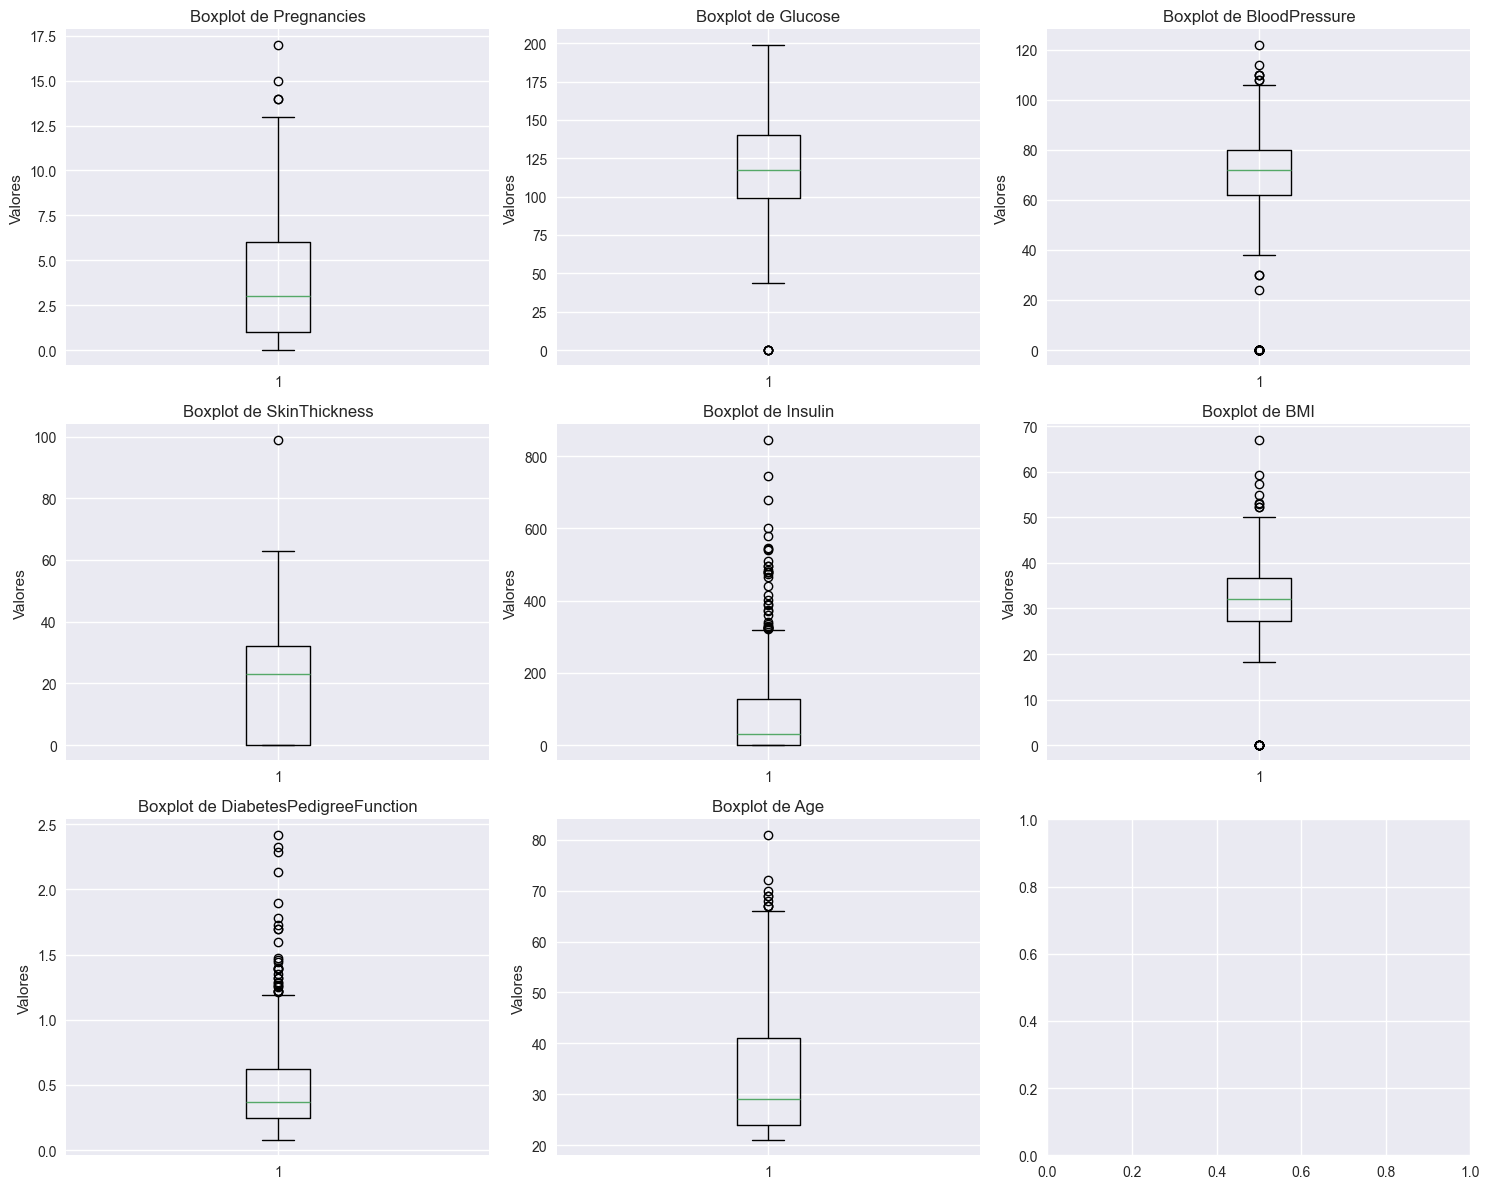

In [5]:
# Visualización de distribuciones

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# Histogramas para cada variable
variables = df.columns[:-1]
for i, col in enumerate(variables):
    axes[i].hist(df[col], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Boxplots para identificar outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(variables):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('Valores')

plt.tight_layout()
plt.show()

In [6]:
# Manejo de valores atípicos y nulos

print("Valores cero por columna (que podrían ser missing):")
for col in variables:
    cero_count = (df[col] == 0).sum()
    if cero_count > 0:
        print(f"{col}: {cero_count} valores cero")

# Reemplazar ceros por NaN en estas columnas
# Glucose, BloodPressure, SkinThickness, Insulin, BMI
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()

for col in columns_to_clean:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Verificar valores nulos después del reemplazo
print("\nValores nulos después de reemplazar ceros:")
print(df_clean.isnull().sum())

# Estrategia para manejar valores nulos: imputación con la mediana
for col in columns_to_clean:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)

print("\nValores nulos después de la imputación:")
print(df_clean.isnull().sum())

Valores cero por columna (que podrían ser missing):
Pregnancies: 111 valores cero
Glucose: 5 valores cero
BloodPressure: 35 valores cero
SkinThickness: 227 valores cero
Insulin: 374 valores cero
BMI: 11 valores cero

Valores nulos después de reemplazar ceros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Valores nulos después de la imputación:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


C:\Users\15-4JO\AppData\Local\Temp\ipykernel_33860\3625791002.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)
C:\Users\15-4JO\AppData\Local\Temp\ipykernel_33860\3625791002.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

Distribución de clases:
Outcome
0    500
1    268
Name: count, dtype: int64


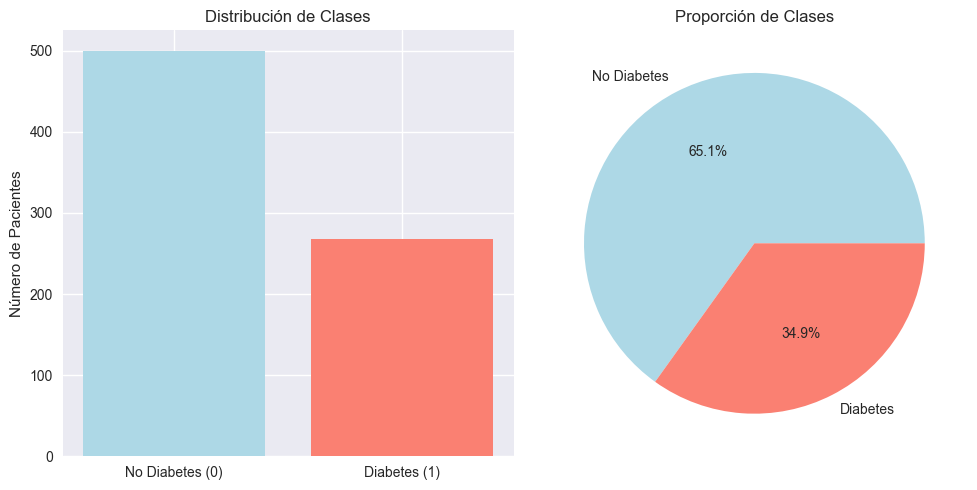


Proporciones:
No Diabetes: 65.10%
Diabetes: 34.90%


In [7]:
# Análisis de balance de clases

class_distribution = df_clean['Outcome'].value_counts()
print("Distribución de clases:")
print(class_distribution)

plt.figure(figsize=(10, 5))

# Gráfico de barras de la distribución de clases
plt.subplot(1, 2, 1)
plt.bar(['No Diabetes (0)', 'Diabetes (1)'], class_distribution.values, 
        color=['lightblue', 'salmon'])
plt.title('Distribución de Clases')
plt.ylabel('Número de Pacientes')

# Gráfico de pie
plt.subplot(1, 2, 2)
plt.pie(class_distribution.values, labels=['No Diabetes', 'Diabetes'], 
        autopct='%1.1f%%', colors=['lightblue', 'salmon'])
plt.title('Proporción de Clases')

plt.tight_layout()
plt.show()

# Calcular proporciones
total = len(df_clean)
diabetes_ratio = class_distribution[1] / total
no_diabetes_ratio = class_distribution[0] / total

print(f"\nProporciones:")
print(f"No Diabetes: {no_diabetes_ratio:.2%}")
print(f"Diabetes: {diabetes_ratio:.2%}")

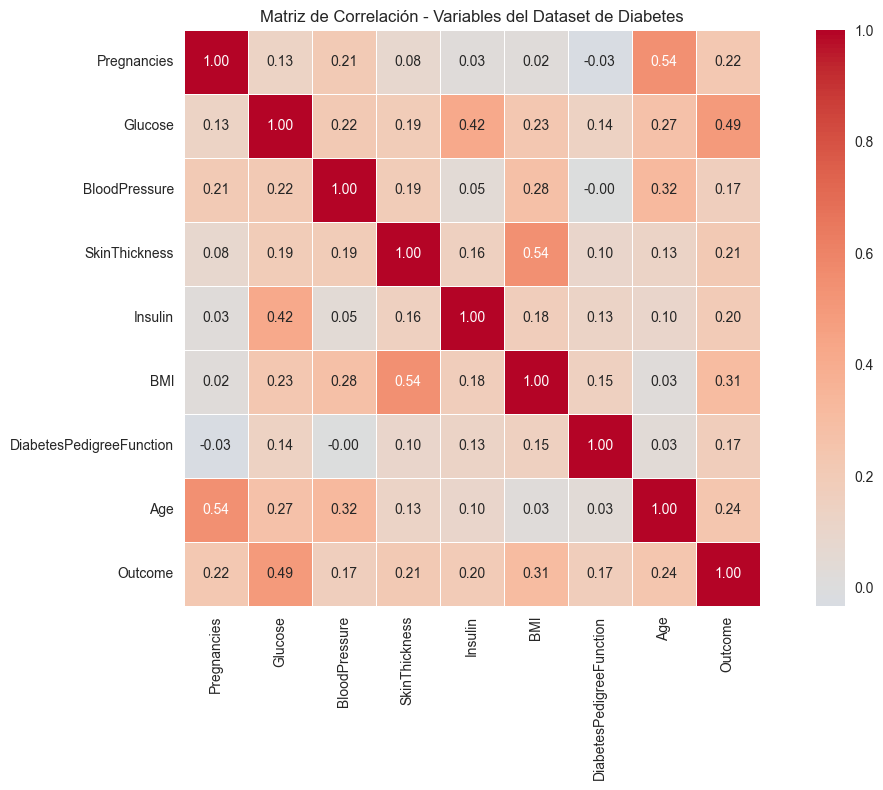


Correlaciones con Outcome (variable objetivo):
Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


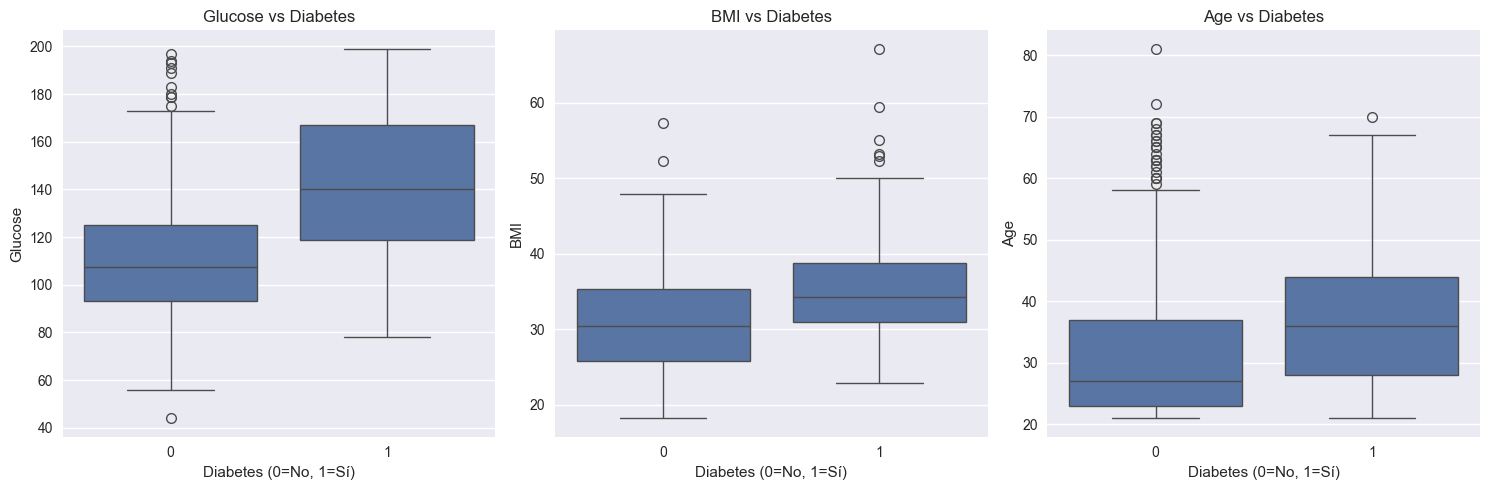

In [8]:
# Matriz de correlación

correlation_matrix = df_clean.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Variables del Dataset de Diabetes')
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print("\nCorrelaciones con Outcome (variable objetivo):")
outcome_correlations = correlation_matrix['Outcome'].sort_values(ascending=False)
print(outcome_correlations)

# Visualización de relaciones importantes
important_vars = outcome_correlations.index[1:4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, var in enumerate(important_vars):
    sns.boxplot(x='Outcome', y=var, data=df_clean, ax=axes[i])
    axes[i].set_title(f'{var} vs Diabetes')
    axes[i].set_xlabel('Diabetes (0=No, 1=Sí)')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

Entrenamiento Se dividio el dataset en el 80% para realizar entrenamiento y el 20% para las pruebas. 

In [9]:

X = df.drop(columns=['Outcome'])
y = df['Outcome']

# ---------------------------------------------------
# 2. Dividir en entrenamiento y prueba
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)
test_data  = pd.concat([X_test, y_test], axis=1)

train_data

test_data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
44,7,159,64,0,0,27.4,0.294,40,0
672,10,68,106,23,49,35.5,0.285,47,0
700,2,122,76,27,200,35.9,0.483,26,0
630,7,114,64,0,0,27.4,0.732,34,1
81,2,74,0,0,0,0.0,0.102,22,0
...,...,...,...,...,...,...,...,...,...
32,3,88,58,11,54,24.8,0.267,22,0
637,2,94,76,18,66,31.6,0.649,23,0
593,2,82,52,22,115,28.5,1.699,25,0
425,4,184,78,39,277,37.0,0.264,31,1


In [10]:
predictor = TabularPredictor(
    label="Outcome",
    eval_metric="accuracy"
).fit(
    train_data,
    time_limit=300,             # límite de tiempo en segundos (ejemplo: 5 min)
    presets="best_quality"      # máxima calidad posible
)


No path specified. Models will be saved in: "AutogluonModels\ag-20250927_180230"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.9.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          12
Memory Avail:       3.05 GB / 15.69 GB (19.4%)
Disk Space Avail:   445.23 GB / 697.68 GB (63.8%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of 

In [11]:
performance_autogluon = predictor.evaluate(test_data)

In [ ]:



lr = LogisticRegression(max_iter=500, solver='liblinear')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("\n--- Comparación de modelos ---")
print("AutoGluon (best_quality) ->", performance_autogluon["accuracy"])
print("Regresión logística      ->", acc_lr)

# ---------------------------------------------------
# 6. Importancia de características
# ---------------------------------------------------
importances = predictor.feature_importance(test_data)
print("\n--- Importancia de variables ---")
print(importances)

Computing feature importance via permutation shuffling for 8 features using 154 rows with 5 shuffle sets...



--- Comparación de modelos ---
AutoGluon (best_quality) -> 0.7532467532467533
Regresión logística      -> 0.7272727272727273


	44.31s	= Expected runtime (8.86s per shuffle set)
	10.88s	= Actual runtime (Completed 5 of 5 shuffle sets)



--- Importancia de variables ---
                            importance    stddev   p_value  n  p99_high  \
Glucose                   1.129870e-01  0.037472  0.001261  5  0.190141   
Age                       2.597403e-02  0.012148  0.004385  5  0.050987   
Insulin                   2.207792e-02  0.008712  0.002391  5  0.040016   
BMI                       1.948052e-02  0.012148  0.011525  5  0.044494   
BloodPressure             1.688312e-02  0.011796  0.016444  5  0.041171   
SkinThickness             2.597403e-03  0.009848  0.293525  5  0.022874   
Pregnancies               1.298701e-03  0.012491  0.413782  5  0.027017   
DiabetesPedigreeFunction  4.440892e-17  0.009183  0.500000  5  0.018908   

                           p99_low  
Glucose                   0.035833  
Age                       0.000961  
Insulin                   0.004140  
BMI                      -0.005533  
BloodPressure            -0.007405  
SkinThickness            -0.017680  
Pregnancies              -0.024

2025-09-27 12:13:42,354	ERROR worker.py:420 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
2025-09-27 12:13:42,360	ERROR worker.py:420 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
2025-09-27 12:13:42,368	ERROR worker.py:420 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
2025-09-27 12:13:42,377	ERROR worker.py:420 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
2025-09-27 12:13:42,387	ERROR worker.py:420 -- Unhandled error (suppress with 'RAY_IGNORE_UN

In [16]:
leaderboard = predictor.leaderboard(test_data, silent=True)
print(leaderboard)

                      model  score_test  score_val eval_metric  \
0            XGBoost_BAG_L1    0.766234   0.788274    accuracy   
1           LightGBM_BAG_L1    0.766234   0.786645    accuracy   
2   RandomForestGini_BAG_L2    0.759740   0.788274    accuracy   
3   RandomForestEntr_BAG_L2    0.759740   0.788274    accuracy   
4   RandomForestEntr_BAG_L1    0.753247   0.757329    accuracy   
5           CatBoost_BAG_L2    0.753247   0.812704    accuracy   
6       WeightedEnsemble_L3    0.753247   0.812704    accuracy   
7   RandomForestGini_BAG_L1    0.746753   0.760586    accuracy   
8           LightGBM_BAG_L2    0.746753   0.798046    accuracy   
9           CatBoost_BAG_L1    0.740260   0.799674    accuracy   
10        LightGBMXT_BAG_L1    0.740260   0.798046    accuracy   
11        LightGBMXT_BAG_L2    0.733766   0.802932    accuracy   
12   NeuralNetFastAI_BAG_L1    0.727273   0.801303    accuracy   
13      WeightedEnsemble_L2    0.727273   0.806189    accuracy   
14    Extr

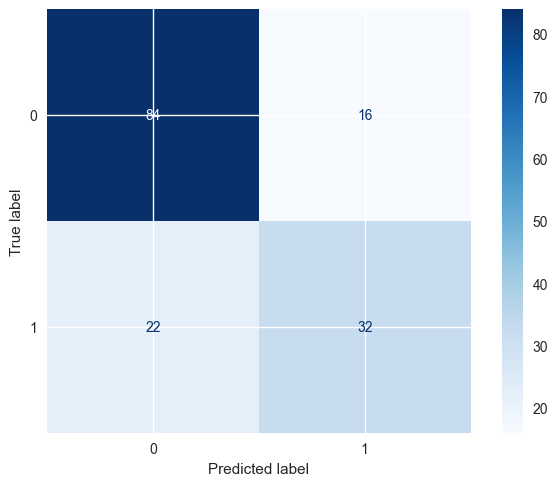

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones en test
y_test = test_data["Outcome"]
y_pred = predictor.predict(test_data)

# Matriz
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7925    0.8400    0.8155       100
           1     0.6667    0.5926    0.6275        54

    accuracy                         0.7532       154
   macro avg     0.7296    0.7163    0.7215       154
weighted avg     0.7483    0.7532    0.7496       154



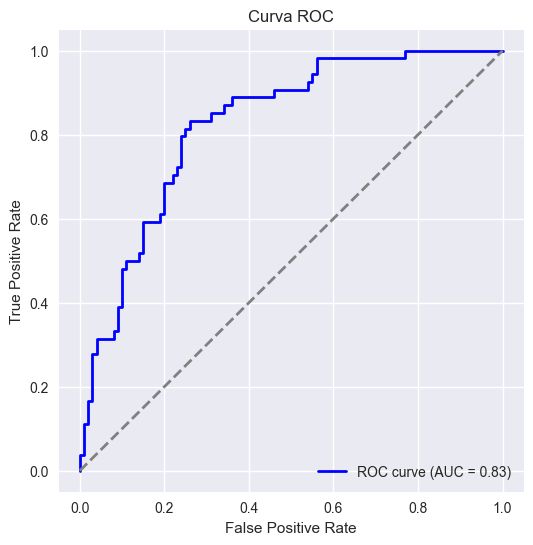

In [19]:
from sklearn.metrics import roc_curve, auc

# Probabilidades de predicción
y_proba = predictor.predict_proba(test_data)[1]  # prob de clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()
